In [1]:
pip install pennylane

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.0/930.0 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 22.3 MB/s eta 0:00:00


In [2]:
pip install yfinance

# Load the Datasets

In [5]:
import pandas as pd
import yfinance as yf

assets = "MSFT BRK-B ASML LLY"
StockStartDate = '2023-01-01'
StockEndDate = '2023-12-31'
interval = '1d'

df = yf.download(assets, start=StockStartDate, end=StockEndDate, interval=interval)

df = df['Close']

# daily return distribution
ret = df.pct_change().dropna()

# mean return vector & covariance matrix (annualized)
R = ret.mean()*252
Sigma = ret.cov()*252

[*********************100%***********************]  4 of 4 completed


# Build VQE

In [6]:
import pennylane as qml
from pennylane import numpy as np

# define parameters in H
N = 4     # number of total assets
gamma = 1  # risk aversion coefficient
B = 1      # budget
P = 1.0    # penalty

ZZ = [qml.PauliZ(i)@qml.PauliZ(j) for i in range(N) for j in range(i+1,N)]
ZZ_coeff = [0.5*(gamma*Sigma.values[i][j] + P) for i in range(N) for j in range(i+1,N)]
Z = [qml.PauliZ(i) for i in range(N)]
Z_coeff = [-0.5*gamma*(sum(Sigma.values[i][:])) + 0.5*R[i] - 0.5*P*(N-2*B) for i in range(N)]
C = 0.25*gamma*(sum(sum(Sigma.values)) + np.trace(Sigma))- 0.5*sum(R) + 0.25*P*(N + (N-2*B)**2)

# Construct the problen Hamiltonian
obs = ZZ + Z
coeffs = ZZ_coeff + Z_coeff
H = qml.Hamiltonian(coeffs, obs, grouping_type="qwc")

<ipython-input-6-fe2ce70df6e6>:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Z_coeff = [-0.5*gamma*(sum(Sigma.values[i][:])) + 0.5*R[i] - 0.5*P*(N-2*B) for i in range(N)]


In [7]:
# Design the ansatz
p = 2     # circuit repetitions
def ansatz(params, qubits, depth=p):
    for q in range(qubits):
            qml.RY(params[q], wires=q)
    for d in range(1,depth+1):
        for q in range(qubits-1):
            qml.CNOT(wires=[q,q+1])
        for q in range(qubits):
            qml.RY(params[d*qubits+q], wires=q)

In [8]:
dev = qml.device("default.qubit", wires=N)

# Set the cost function on dev
@qml.qnode(dev, diff_method="parameter-shift")
def cost(x):
    ansatz(x, qubits=N)
    return qml.expval(H)

# For analyze the optimized circuit
@qml.qnode(dev)
def probability_circuit(params):
    ansatz(params, qubits=N)
    return qml.probs(wires=range(N))

# Compute Process

In [9]:
opt = qml.QNGOptimizer(stepsize=0.02)
max_steps=1000
init_params = np.random.rand((p+1)*N)

params = init_params
old_cost = 9999.999999
for i in range(max_steps):
    params = opt.step(cost, params)
    obj_value = cost(params)
    if (i + 1) % 5 == 0:
        print("Cost after step {:5d}: {: .7f}".format(i + 1, obj_value))
        if np.round(old_cost, 7) == np.round(obj_value, 7):
            break
        else:
            old_cost = obj_value

print("Optimized parameters: {}".format(params))
print("Optimized objective function value: {}".format(obj_value))

Cost after step     5: -0.8183371
Cost after step    10: -1.2784792
Cost after step    15: -1.5719725
Cost after step    20: -1.7018037
Cost after step    25: -1.7560450
Cost after step    30: -1.7826435
Cost after step    35: -1.7983842
Cost after step    40: -1.8088737
Cost after step    45: -1.8162044
Cost after step    50: -1.8213811
Cost after step    55: -1.8250249
Cost after step    60: -1.8275726
Cost after step    65: -1.8293421
Cost after step    70: -1.8305648
Cost after step    75: -1.8314066
Cost after step    80: -1.8319853
Cost after step    85: -1.8323835
Cost after step    90: -1.8326583
Cost after step    95: -1.8328491
Cost after step   100: -1.8329829
Cost after step   105: -1.8330779
Cost after step   110: -1.8331466
Cost after step   115: -1.8331973
Cost after step   120: -1.8332357
Cost after step   125: -1.8332656
Cost after step   130: -1.8332896
Cost after step   135: -1.8333094
Cost after step   140: -1.8333262
Cost after step   145: -1.8333408
Cost after ste

# Result Report

Final solution : 0010, with prob=0.96667


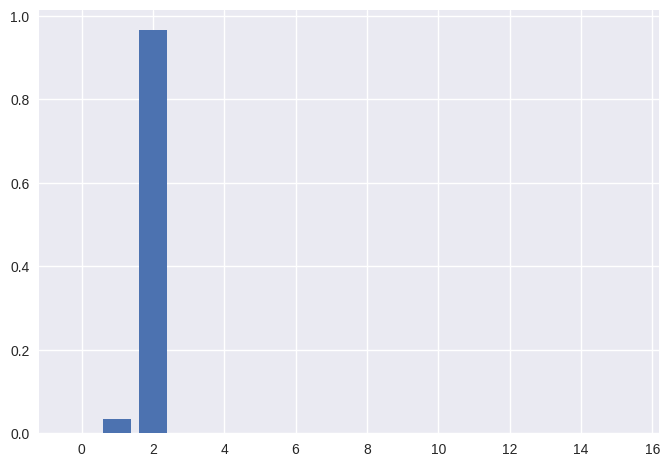

In [11]:
import matplotlib.pyplot as plt

probs = probability_circuit(params)
print("Final solution : {:04b}, with prob={:.5f}".format(np.argmax(probs), max(probs)))
plt.style.use("seaborn-v0_8")
plt.bar(range(2 ** len(range(N))), probs)
plt.show()

In [12]:
import itertools
all_combinations = itertools.product([0, 1], repeat=N)

E_g = 99999.99999
for x in all_combinations:
    E = gamma*np.dot(x, np.dot(Sigma, x)) - np.dot(R,x) + P*(sum(x)-B)**2
    if E < E_g:
        E_g = E
        sol = x
print("Exact solution:{}".format(sol))

Exact solution:(0, 0, 1, 0)


Dari hasil di atas, disimpulkan bahwa potofolio yang direkomendasi berdasarkan data dari tanggal 1 Januari 2023 sampai 31 Desember 2023 yaitu ASML.